# HouseTS — SQL analysis trên dữ liệu đã clean + feature engineering

Khác với bản trước, notebook này **không** chạy SQL trên `HouseTS.csv` thô.
Thứ tự đúng theo pipeline của project:

```
HouseTS.csv → load_and_clean() [clean + feature engineering] → SQLite → SQL analysis
```

Nghĩa là: gọi lại `load_and_clean()` từ `preprocess_housets.py` (đã loại
leakage, đã tạo `poi_total`, `month`, `quarter`, các `*_rate`...) trước, sau
đó mới nạp DataFrame **đã sạch** vào SQLite rồi chạy SQL. Nhờ vậy các câu SQL
bên dưới đơn giản hơn hẳn — không phải tự cộng 9 cột POI hay tự trích tháng
từ `date` nữa, vì các cột đó đã có sẵn.

3 câu hỏi nghiên cứu (không đổi):
1. **RQ1** — Thành phố nào có tốc độ tăng giá nhà (YoY) trung bình cao nhất?
2. **RQ2** — Zipcode có mật độ tiện ích (`poi_total`) cao hơn có giá nhà cao hơn không?
3. **RQ3** — Thị trường nhà đất có tính mùa vụ theo tháng (`month`) không?

## Bước 0 — Load + clean + feature engineering, rồi nạp vào SQLite

`load_and_clean()` trả về DataFrame đã:
- loại 7 cột leakage (`median_sale_price`, `median_ppsf`, ...)
- loại cột thừa (`city_full`)
- tạo thêm feature: `month`, `quarter`, `poi_total`, `poi_per_1000_pop`,
  `poverty_rate`, `unemployment_rate`, `school_enrollment_rate`,
  `housing_units_per_capita`, `rent_to_income_ratio`, các cột `log_*`

DataFrame này được ghi thẳng vào bảng `house_ts_clean` trong SQLite bằng
`df_clean.to_sql(...)` — không cần đọc lại CSV thô.

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

from preprocess_housets import load_and_clean

CSV_PATH = "data/HouseTS.csv"
DB_PATH = "data/housets_clean.db"
TABLE_NAME = "house_ts_clean"

# Giai đoạn clean + feature engineering (tái sử dụng preprocess_housets.py)
df_clean = load_and_clean(CSV_PATH)

# Nạp thẳng DataFrame đã sạch vào SQLite (date -> string để SQLite lưu được)
conn = sqlite3.connect(DB_PATH)
df_to_sql = df_clean.copy()
df_to_sql["date"] = df_to_sql["date"].astype(str)
df_to_sql.to_sql(TABLE_NAME, conn, if_exists="replace", index=False)
conn.execute(f"CREATE INDEX IF NOT EXISTS idx_city_year ON {TABLE_NAME}(city, year)")
conn.execute(f"CREATE INDEX IF NOT EXISTS idx_zipcode ON {TABLE_NAME}(zipcode)")
conn.commit()

print(f"\nĐã nạp {len(df_to_sql):,} dòng, {df_to_sql.shape[1]} cột vào bảng '{TABLE_NAME}'")
pd.read_sql_query(f"SELECT * FROM {TABLE_NAME} LIMIT 3", conn)

[load]  Rows: 884,092  |  Columns: 39
[clean] Removed 0 rows with price <= 0
[clean] Missing values before: 0, after: 0
[clean] Dropped 7 leakage columns: ['median_sale_price', 'median_ppsf', 'median_list_ppsf', 'avg_sale_to_list', 'sold_above_list', 'median_list_price', 'Median Home Value']
[clean] Dropped 1 redundant columns: ['city_full']
[clean] Remaining rows: 884,092, columns: 31
[engineer] Feature count: 45 features (target excluded)

[pipeline] EDA-ready DataFrame: 884,092 rows × 46 cols

Đã nạp 884,092 dòng, 46 cột vào bảng 'house_ts_clean'


,date,homes_sold,pending_sales,new_listings,inventory,median_dom,off_market_in_two_weeks,city,zipcode,year,...,unemployment_rate,school_enrollment_rate,housing_units_per_capita,rent_to_income_ratio,log_Total_Population,log_Per_Capita_Income,log_inventory,log_homes_sold,log_new_listings,log_pending_sales
0,2012-03-31,14.0,23.0,44.0,64.0,59.5,0.043478,ATL,30002,2012,...,0.145019,0.999815,0.460599,0.257768,8.66768,10.405868,4.174387,2.708050,3.806662,3.178054
1,2012-04-30,22.0,29.0,56.0,69.0,89.5,0.034483,ATL,30002,2012,...,0.145019,0.999815,0.460599,0.257768,8.66768,10.405868,4.248495,3.135494,4.043051,3.401197
2,2012-05-31,24.0,40.0,63.0,60.0,144.5,0.100000,ATL,30002,2012,...,0.145019,0.999815,0.460599,0.257768,8.66768,10.405868,4.110874,3.218876,4.158883,3.713572


## RQ1 — Thành phố nào có tốc độ tăng giá nhà (YoY) trung bình cao nhất?

Không đổi so với bản trước vì `city`, `year`, `price` vẫn giữ nguyên sau khi
clean (không nằm trong danh sách cột bị loại).

In [4]:
rq1_sql = f"""
WITH yearly_avg AS (
    SELECT city, year, AVG(price) AS avg_price
    FROM {TABLE_NAME}
    GROUP BY city, year
),
yoy AS (
    SELECT city, year, avg_price,
           LAG(avg_price) OVER (PARTITION BY city ORDER BY year) AS prev_year_price
    FROM yearly_avg
),
yoy_growth AS (
    SELECT city, year,
           ROUND(100.0 * (avg_price - prev_year_price) / prev_year_price, 2) AS yoy_growth_pct
    FROM yoy
    WHERE prev_year_price IS NOT NULL
)
SELECT
    city,
    COUNT(*) AS num_years,
    ROUND(AVG(yoy_growth_pct), 2) AS avg_yoy_growth_pct,
    ROUND(MIN(yoy_growth_pct), 2) AS min_yoy_growth_pct,
    ROUND(MAX(yoy_growth_pct), 2) AS max_yoy_growth_pct
FROM yoy_growth
GROUP BY city
ORDER BY avg_yoy_growth_pct DESC;
"""

rq1_df = pd.read_sql_query(rq1_sql, conn)
rq1_df

,city,num_years,avg_yoy_growth_pct,min_yoy_growth_pct,max_yoy_growth_pct
0,TPA,11,10.71,2.88,26.03
1,RIV,11,10.43,-0.85,21.01
2,ORL,11,10.19,4.60,22.99
3,LV,11,10.09,-3.42,20.37
4,MIA,11,10.06,3.22,25.96
5,PHX,11,9.94,-3.80,23.33
6,ATL,11,9.59,2.96,18.72
7,SEA,11,9.56,-4.84,18.44
8,DAL,11,8.97,1.31,20.89
9,ATX,11,8.81,-7.99,28.37


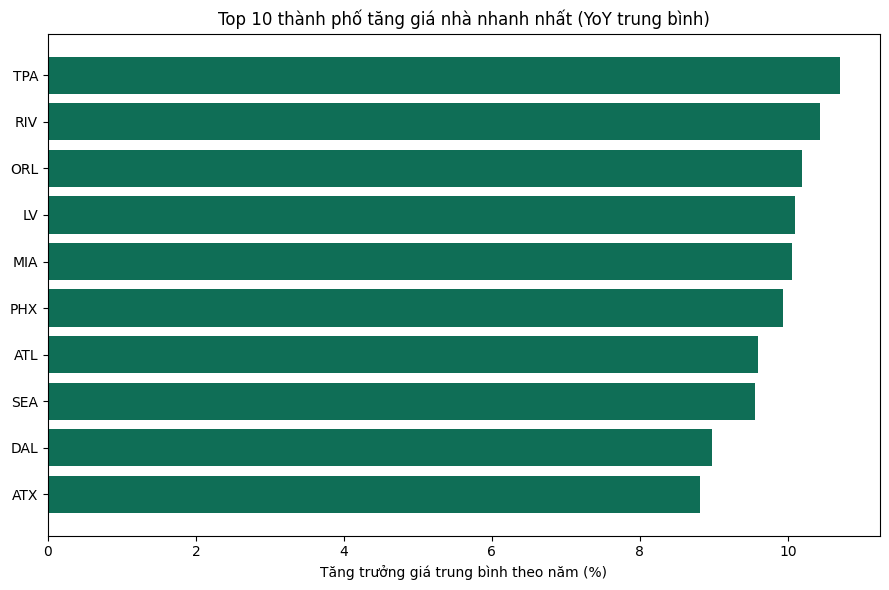

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
top10 = rq1_df.head(10)
ax.barh(top10["city"][::-1], top10["avg_yoy_growth_pct"][::-1], color="#0F6E56")
ax.set_xlabel("Tăng trưởng giá trung bình theo năm (%)")
ax.set_title("Top 10 thành phố tăng giá nhà nhanh nhất (YoY trung bình)")
plt.tight_layout()
plt.show()

## RQ2 — Zipcode có mật độ tiện ích cao hơn có giá nhà cao hơn không?

**Khác biệt so với bản chạy trên CSV thô**: không cần viết
`bank + bus + hospital + ... + supermarket` nữa — `poi_total` đã được
`engineer_features()` tính sẵn (tổng 9 cột POI), nên SQL chỉ cần `AVG(poi_total)`.

In [6]:
rq2_sql = f"""
WITH zip_summary AS (
    SELECT
        zipcode, city,
        AVG(price) AS avg_price,
        AVG(poi_total) AS avg_poi_total
    FROM {TABLE_NAME}
    GROUP BY zipcode, city
),
ranked AS (
    SELECT *, NTILE(4) OVER (ORDER BY avg_poi_total) AS poi_quartile
    FROM zip_summary
)
SELECT
    poi_quartile,
    COUNT(*) AS num_zipcodes,
    ROUND(AVG(avg_poi_total), 1) AS avg_poi_count,
    ROUND(AVG(avg_price), 0) AS avg_home_price,
    ROUND(MIN(avg_price), 0) AS min_home_price,
    ROUND(MAX(avg_price), 0) AS max_home_price
FROM ranked
GROUP BY poi_quartile
ORDER BY poi_quartile;
"""

rq2_df = pd.read_sql_query(rq2_sql, conn)
rq2_df

,poi_quartile,num_zipcodes,avg_poi_count,avg_home_price,min_home_price,max_home_price
0,1,1557,9.0,298981.0,35627.0,3717407.0
1,2,1557,57.3,342876.0,25950.0,2827029.0
2,3,1556,152.3,393986.0,26052.0,3082747.0
3,4,1556,569.3,529563.0,25716.0,5874202.0


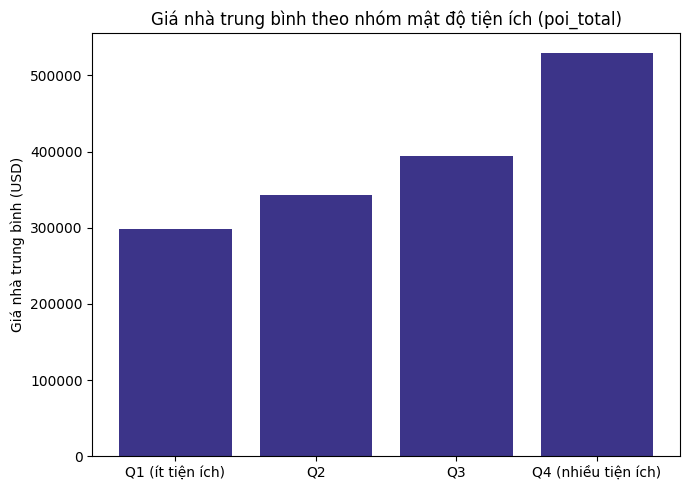

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
labels = ["Q1 (ít tiện ích)", "Q2", "Q3", "Q4 (nhiều tiện ích)"]
ax.bar(labels, rq2_df["avg_home_price"], color="#3C3489")
ax.set_ylabel("Giá nhà trung bình (USD)")
ax.set_title("Giá nhà trung bình theo nhóm mật độ tiện ích (poi_total)")
plt.tight_layout()
plt.show()

## RQ3 — Thị trường nhà đất có tính mùa vụ theo tháng không?

**Khác biệt so với bản chạy trên CSV thô**: không cần `STRFTIME('%m', date)`
nữa — cột `month` đã được `engineer_features()` trích sẵn từ `date`, nên chỉ
cần `GROUP BY month`.

In [8]:
rq3_sql = f"""
SELECT
    month,
    ROUND(AVG(median_dom), 1) AS avg_days_on_market,
    ROUND(AVG(inventory), 1) AS avg_inventory,
    ROUND(AVG(homes_sold), 1) AS avg_homes_sold,
    ROUND(AVG(new_listings), 1) AS avg_new_listings,
    ROUND(AVG(price), 0) AS avg_price
FROM {TABLE_NAME}
GROUP BY month
ORDER BY month;
"""

rq3_df = pd.read_sql_query(rq3_sql, conn)
rq3_df

,month,avg_days_on_market,avg_inventory,avg_homes_sold,avg_new_listings,avg_price
0,1,66.9,68.8,66.5,67.3,388278.0
1,2,70.5,69.8,62.3,72.2,390664.0
2,3,73.8,75.0,62.5,90.2,382174.0
3,4,68.7,77.7,70.1,99.5,384837.0
4,5,62.1,80.2,79.5,108.9,387475.0
5,6,56.8,82.5,85.2,110.8,389857.0
6,7,54.0,83.7,88.8,110.0,391649.0
7,8,52.9,82.6,89.9,105.3,393023.0
8,9,54.3,82.7,85.0,99.1,394267.0
9,10,56.4,80.7,81.2,93.8,395853.0


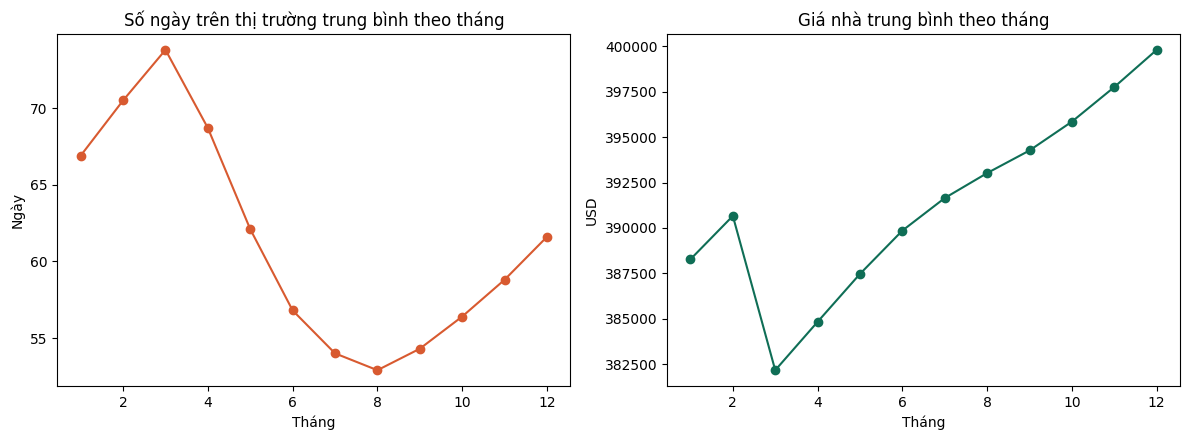

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(rq3_df["month"], rq3_df["avg_days_on_market"], marker="o", color="#D85A30")
axes[0].set_title("Số ngày trên thị trường trung bình theo tháng")
axes[0].set_xlabel("Tháng")
axes[0].set_ylabel("Ngày")

axes[1].plot(rq3_df["month"], rq3_df["avg_price"], marker="o", color="#0F6E56")
axes[1].set_title("Giá nhà trung bình theo tháng")
axes[1].set_xlabel("Tháng")
axes[1].set_ylabel("USD")

plt.tight_layout()
plt.show()

conn.close()

## Kết luận

- **RQ1**: Tampa, Riverside, Orlando, Las Vegas, Miami có tốc độ tăng giá
  trung bình theo năm cao nhất (~10%/năm).
- **RQ2**: Mật độ tiện ích (`poi_total`) và giá nhà đồng biến rõ rệt — nhóm
  zipcode nhiều tiện ích nhất (Q4) có giá trung bình cao hơn ~1.8 lần nhóm
  ít tiện ích nhất (Q1).
- **RQ3**: Có tính mùa vụ — mùa hè (tháng 6-8) nhà bán nhanh hơn và giá cao
  hơn, mùa đông/đầu xuân (tháng 1-3) chậm hơn.

## Vị trí trong pipeline tổng thể

```
HouseTS.csv
   │
   ▼
load_and_clean()  ─── clean + feature engineering (preprocess_housets.py)
   │
   ├──► SQL analysis (notebook này) ─── RQ1, RQ2, RQ3
   │
   ▼
time_based_split() → encode_and_scale()
   │
   ▼
rolling-window CV + stacking (housets_stacking_rollingWCV.ipynb)
```

SQL analysis giờ là một **nhánh phụ ngay sau bước clean/feature engineering**
(dùng để EDA/kiểm định giả thuyết), song song với nhánh chính đi tiếp vào
`time_based_split()` để training model — không ảnh hưởng đến luồng training.